In [1]:
%run ./load_local.py -w

import importlib
from geolayer.layer import vector_layer

In [2]:
importlib.reload(vector_layer)
vector_layer.VectorLayer.layer('/data/NUTS_RG_03M_2021_4326_0.shp')

{'extent': [-63.151764, 55.83509, -21.386955, 80.834265],
 'feature_count': 37,
 'geom_type': 3,
 'geom_type_name': 'Polygon',
 'geometry_column': '',
 'spatial_ref': 'GEOGCS["WGS 84",\n    DATUM["WGS_1984",\n        SPHEROID["WGS 84",6378137,298.257223563,\n            AUTHORITY["EPSG","7030"]],\n        AUTHORITY["EPSG","6326"]],\n    PRIMEM["Greenwich",0,\n        AUTHORITY["EPSG","8901"]],\n    UNIT["degree",0.0174532925199433,\n        AUTHORITY["EPSG","9122"]],\n    AXIS["Latitude",NORTH],\n    AXIS["Longitude",EAST],\n    AUTHORITY["EPSG","4326"]]',
 'epsg': '4326',
 'feature_type': 'Polygon'}

### Shapefile

In [13]:
import plotly.express as px
from vois.geo import Map
importlib.reload(vector_layer)

vlayer = vector_layer.VectorLayer.file('/data/NUTS_RG_03M_2021_4326_0.shp') #, epsg=4326, proj='+init=epsg:4326')

symbol = [
            [
               ["PolygonSymbolizer", "fill", 'FILL-COLOR'],
               ["PolygonSymbolizer", "fill-opacity", 0.8],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 1.0]
            ]
]

symbol = [
              [('PolygonSymbolizer', 'fill', 'COLOR'),
               ('PolygonSymbolizer', 'fill-opacity', '1.0'),
               ('LineSymbolizer', 'stroke', '#000000'),
               ('LineSymbolizer', 'stroke-width', '0.0')],
              [('MarkersSymbolizer', 'file', '/symbols/material-design-icons/svg/filled/church.svg'),
                ('MarkersSymbolizer', 'fill', 'COLOR'),
                ('MarkersSymbolizer', 'fill-opacity', '1.0'),
                ('MarkersSymbolizer', 'stroke', '#000000'),
                ('MarkersSymbolizer', 'stroke-width', '1'),
                ('MarkersSymbolizer', 'stroke-opacity', '1.0'),
                ('MarkersSymbolizer', 'width', '18'),
                ('MarkersSymbolizer', 'height', '26'),
                ('MarkersSymbolizer', 'placement', 'line'),
                ('MarkersSymbolizer', 'offset', -20),
                ('MarkersSymbolizer', 'spacing', 20),
                ('MarkersSymbolizer', 'allow-overlap', 'true'),]
]

#display(vlayer.fields())
#display(vlayer.field('CNTR_CODE'))
#display(vlayer.values('CNTR_CODE'))
#display(vlayer.distinct('CNTR_CODE'))
#display(vlayer.stats('FID'))


#vlayer.symbologyClear()
#vlayer.symbologyAdd(symbol=VectorLayer.symbolChange(symbol, fillColor='red'))
#vlayer.symbologyAdd(rule="[CNTR_CODE] = 'IT'", symbol=VectorLayer.symbolChange(symbol, fillColor='#00aa00'))

legend = vlayer.legendCategories('CNTR_CODE', px.colors.qualitative.Dark24, symbol=symbol, interpolate=False)


aaa = '''
m = Map.Map()
m.addLayer(vlayer)
vlayer.identify_width = '220px'
m.onclick = vlayer.onclick
#vlayer.identify_fields = ['FID', 'CNTR_CODE']
m
'''

#vlayer.print()
print(vlayer.xml())

<?xml version="1.0" encoding="utf-8"?>
<!DOCTYPE Map[]>
<Map srs="+proj=merc +a=6378137 +b=6378137 +lat_ts=0.0 +lon_0=0.0 +x_0=0.0 +y_0=0.0 +k=1.0 +units=m +nadgrids=@null +wktext +no_defs +over" background-color="#ffffff00" maximum-extent="-20037508.34,-20037508.34,20037508.34,20037508.34" buffer-size="50">
    <Parameters>
        <Parameter name="bounds">-180,-85.05112877980659,180,85.05112877980659</Parameter>
        <Parameter name="center">0,0,2</Parameter>
        <Parameter name="format">png</Parameter>
        <Parameter name="minzoom">0</Parameter>
        <Parameter name="maxzoom">22</Parameter>
        <Parameter name="description">TILEGEO/GEOLAYER display system</Parameter>
    </Parameters>

    <Style name="31e78242649d44aed1275279c318b4a5_0">
        <Rule>
            <Filter>[CNTR_CODE] = 'AL'</Filter>
            <LineSymbolizer stroke="#000000" stroke-width="0.0"/>
            <PolygonSymbolizer fill="#2E91E5" fill-opacity="1.0"/>
        </Rule>
        <Rule>
   

In [ ]:
from ipyleaflet import Map, basemaps, basemap_to_tiles

m = Map(
    basemap=basemap_to_tiles(basemaps.NASAGIBS.ModisTerraTrueColorCR, "2017-04-08"),
    center=(52.204793, 360.121558),
    zoom=4
)

m

In [ ]:
!conda env list

In [ ]:
vlayer.legend2Image(legend, size=1, fontsize=13, fontweight=400, width=400)

In [ ]:
vlayer.legend2List(legend)

### Geopackage

In [16]:
from vois.geo import Map
importlib.reload(vector_layer)

vlayer = vector_layer.VectorLayer.file('/data/IsleofMan.gpkg', layer='31311023') #, epsg=4258, proj='+init=epsg:4258')

symbol = [
            [
               ["PolygonSymbolizer", "fill", 'FILL-COLOR'],
               ["PolygonSymbolizer", "fill-opacity", 0.8],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 1.0]
            ]
]

#display(vlayer.fields())

legend = vlayer.legendSingle(symbol=vector_layer.VectorLayer.symbolChange(symbol, fillColor='#00aa00'))

#vlayer.print()

'''m = Map.Map()
m.addLayer(vlayer)
m.onclick = vlayer.onclick
#vlayer.identify_fields = ['FID', 'CNTR_CODE']
m'''

print(vlayer.xml())

<?xml version="1.0" encoding="utf-8"?>
<!DOCTYPE Map[]>
<Map srs="+proj=merc +a=6378137 +b=6378137 +lat_ts=0.0 +lon_0=0.0 +x_0=0.0 +y_0=0.0 +k=1.0 +units=m +nadgrids=@null +wktext +no_defs +over" background-color="#ffffff00" maximum-extent="-20037508.34,-20037508.34,20037508.34,20037508.34" buffer-size="50">
    <Parameters>
        <Parameter name="bounds">-180,-85.05112877980659,180,85.05112877980659</Parameter>
        <Parameter name="center">0,0,2</Parameter>
        <Parameter name="format">png</Parameter>
        <Parameter name="minzoom">0</Parameter>
        <Parameter name="maxzoom">22</Parameter>
        <Parameter name="description">TILEGEO/GEOLAYER display system</Parameter>
    </Parameters>

    <Style name="c7509f587d1e864b1e16c10b52feefc0_0" comp-op="src-over">
        <Rule>
            <LineSymbolizer stroke="#000000" stroke-width="1.0"/>
            <PolygonSymbolizer fill="#00aa00" fill-opacity="0.8"/>
        </Rule>
    </Style>

    <Layer name="c7509f587d1e864b

In [105]:
from vois.geo import Map
importlib.reload(vector_layer)

vlayer = vector_layer.VectorLayer.file('/data/dbsm-v1-malta-merge.gpkg')
symbol = [
            [
               ["PolygonSymbolizer", "fill", 'FILL-COLOR'],
               ["PolygonSymbolizer", "fill-opacity", 0.8],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 1.0]
            ]
]

#display(vlayer.fields())

legend = vlayer.legendSingle(symbol=vector_layer.VectorLayer.symbolChange(symbol, fillColor='#00aa00'))

#vlayer.print()

'''m = Map.Map()
m.addLayer(vlayer)
m.onclick = vlayer.onclick
#vlayer.identify_fields = ['FID', 'CNTR_CODE']
m'''

print(vlayer.xml())

<?xml version="1.0" encoding="utf-8"?>
<!DOCTYPE Map[]>
<Map srs="+proj=merc +a=6378137 +b=6378137 +lat_ts=0.0 +lon_0=0.0 +x_0=0.0 +y_0=0.0 +k=1.0 +units=m +nadgrids=@null +wktext +no_defs +over" background-color="#ffffff00" maximum-extent="-20037508.34,-20037508.34,20037508.34,20037508.34" buffer-size="50">
    <Parameters>
        <Parameter name="bounds">-180,-85.05112877980659,180,85.05112877980659</Parameter>
        <Parameter name="center">0,0,2</Parameter>
        <Parameter name="format">png</Parameter>
        <Parameter name="minzoom">0</Parameter>
        <Parameter name="maxzoom">22</Parameter>
        <Parameter name="description">TILEGEO/GEOLAYER display system</Parameter>
    </Parameters>

    <Style name="f93f33e2b130dfb532e35d56fce5ff4d_0">
        <Rule>
            <PolygonSymbolizer fill="#00aa00" fill-opacity="0.8"/>
            <LineSymbolizer stroke="#000000" stroke-width="1.0"/>
        </Rule>
    </Style>

    <Layer name="f93f33e2b130dfb532e35d56fce5ff4d" s

### SQLITE

In [14]:
import plotly.express as px
from vois.geo import Map
importlib.reload(vector_layer)

vlayer = vector_layer.VectorLayer.file('/data/BA_effis.sqlite', layer='2016', epsg=3035)

symbol = [
            [
               ["PolygonSymbolizer", "fill", 'FILL-COLOR'],
               ["PolygonSymbolizer", "fill-opacity", 0.8],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 1.0]
            ]
]

#display(vlayer.fields())
#display(vlayer.field('ICC'))
#display(vlayer.values('ICC'))
#display(vlayer.distinct('ICC'))
#display(vlayer.stats('OBJECTID'))


#vlayer.symbologyClear()
#vlayer.symbologyAdd(symbol=vectorlayer.symbolChange(symbol, fillColor='red'))
##vlayer.symbologyAdd(rule="[CNTR_CODE] = 'IT'", symbol=vectorlayer.symbolChange(symbol, fillColor='#00aa00'))

legend = vlayer.legendGraduated('area_ha', px.colors.sequential.Viridis, symbol=symbol, interpolate=True, classifier_name='Quantiles', classifier_param1=8, digits=2)
#legend = vlayer.legendSingle(symbol=vector_layer.VectorLayer.symbolChange(symbol, fillColor='#00aa00'))

#vlayer.print()

'''
m = Map.Map()
m.addLayer(vlayer)
m.onclick = vlayer.onclick
#vlayer.identify_fields = ['FID', 'CNTR_CODE']
m
'''
print(vlayer.xml())

<?xml version="1.0" encoding="utf-8"?>
<!DOCTYPE Map[]>
<Map srs="+proj=merc +a=6378137 +b=6378137 +lat_ts=0.0 +lon_0=0.0 +x_0=0.0 +y_0=0.0 +k=1.0 +units=m +nadgrids=@null +wktext +no_defs +over" background-color="#ffffff00" maximum-extent="-20037508.34,-20037508.34,20037508.34,20037508.34" buffer-size="50">
    <Parameters>
        <Parameter name="bounds">-180,-85.05112877980659,180,85.05112877980659</Parameter>
        <Parameter name="center">0,0,2</Parameter>
        <Parameter name="format">png</Parameter>
        <Parameter name="minzoom">0</Parameter>
        <Parameter name="maxzoom">22</Parameter>
        <Parameter name="description">TILEGEO/GEOLAYER display system</Parameter>
    </Parameters>

    <Style name="73589a74d758f04a196dabe8677713de_0">
        <Rule>
            <Filter>[area_ha] &lt;= 53.0</Filter>
            <LineSymbolizer stroke="#000000" stroke-width="1.0"/>
            <PolygonSymbolizer fill="#440154" fill-opacity="0.8"/>
        </Rule>
        <Rule>
 

In [5]:
import math
zoom = 10
tile_dimension_in_degree = 360.0/math.pow(2, zoom)
tolerance = tile_dimension_in_degree / 100.0
print(tolerance)
vlayer.identify(lon=-8.0, lat=41.0, tolerance=tolerance)

0.003515625


{'FID': 35,
 'geom': 'POLYGON ((2817041.11465387 2170087.17708147,2817062.06968525 2169992.87933913,2817208.75500604 2169919.5367293,2817259.04714203 2169869.24459331,2817376.39535821 2169617.78411561,2817376.39535821 2169344.76976423,2817443.45143841 2169282.50341127,2817611.09179058 2169014.27888824,2817544.03571039 2168695.76222923,2817275.81118736 2168544.88592239,2817141.69892585 2168243.1333087,2817158.46287005 2167941.38079614,2817158.46287005 2167639.62818246,2816890.23834703 2167455.22378496,2816554.95774381 2167539.04391048,2816437.6094265 2167824.03247884,2816186.14894881 2168041.964967,2816001.7445513 2168310.18949002,2815850.86834558 2168578.41401305,2815800.5762096 2168595.17805838,2815742.83130818 2168883.90256544,2815645.8580897 2168901.0154804,2815556.51621744 2169204.77758316,2815556.51621744 2169508.53968592,2815520.77952921 2169830.17018336,2815502.91113453 2170133.93228612,2815556.51621744 2170455.56268244,2815610.12130035 2170759.3247852,2815610.12130035 2171063.0

In [6]:
legend

[{'description': '<= 53.00',
  'rule': '[area_ha] &lt;= 53.0',
  'symbol': [[('PolygonSymbolizer', 'fill', '#440154'),
    ('PolygonSymbolizer', 'fill-opacity', 0.8),
    ('LineSymbolizer', 'stroke', '#000000'),
    ('LineSymbolizer', 'stroke-width', 1.0)]]},
 {'description': '53.00 - 78.00',
  'rule': '[area_ha] &gt; 53.0 and [area_ha] &lt;= 78.0',
  'symbol': [[('PolygonSymbolizer', 'fill', '#45317c'),
    ('PolygonSymbolizer', 'fill-opacity', 0.8),
    ('LineSymbolizer', 'stroke', '#000000'),
    ('LineSymbolizer', 'stroke-width', 1.0)]]},
 {'description': '78.00 - 111.00',
  'rule': '[area_ha] &gt; 78.0 and [area_ha] &lt;= 111.0',
  'symbol': [[('PolygonSymbolizer', 'fill', '#365a8b'),
    ('PolygonSymbolizer', 'fill-opacity', 0.8),
    ('LineSymbolizer', 'stroke', '#000000'),
    ('LineSymbolizer', 'stroke-width', 1.0)]]},
 {'description': '111.00 - 160.00',
  'rule': '[area_ha] &gt; 111.0 and [area_ha] &lt;= 160.0',
  'symbol': [[('PolygonSymbolizer', 'fill', '#277e8e'),
    ('Po

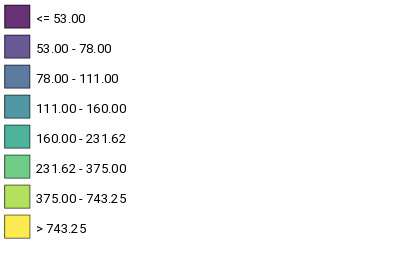

In [15]:
vlayer.legend2Image(legend, size=1, fontsize=13, fontweight=400, width=400)

In [8]:
def onclick(widget, event, data):
    print(legend[widget.value])

vlayer.legend2List(legend, title='Legend', size=1, onclick=onclick)

List(children=[Subheader(children=['Legend'], class_='pa-0 ma-0 mb-n2', layout=None, style_='font-size: 14px; …

In [ ]:
vlayer

### WKT strings

In [9]:
import plotly.express as px
from vois.geo import Map
importlib.reload(vector_layer)

vlayer = vector_layer.VectorLayer.wkt(['POLYGON ((20 40, 0 45, 10 52, 30 52, 20 40))',
                                       'POLYGON ((10 40, 5 45, 15 52, 20 32, 28 30))'],
                                      [{"ndx": 22, "value": 12.8798, "units": "abcd", "type": "type1"}])

symbol = [
            [
               ["PolygonSymbolizer", "fill", 'FILL-COLOR'],
               ["PolygonSymbolizer", "fill-opacity", 0.2],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 4.0]
            ]
]

#display(vlayer.fields())
#display(vlayer.field('units'))
#display(vlayer.values('units'))
#display(vlayer.distinct('units'))
#display(vlayer.stats('ndx'))

vlayer.symbologyClear()
#vlayer.symbologyAdd(symbol=vectorlayer.symbolChange(symbol, fillColor='#ff0000'))
vlayer.symbologyAdd(rule="[units] = 'abcd'", symbol=vector_layer.VectorLayer.symbolChange(symbol, fillColor='#0088ff'))

'''
m = Map.Map(center=[46,15])
m.addLayer(vlayer)
m.onclick = vlayer.onclick
vlayer.identify_fields = ['FID', 'GEOMETRY', 'ndx']
m
'''

#vlayer.print()
print(vlayer.xml())

<?xml version="1.0" encoding="utf-8"?>
<!DOCTYPE Map[]>
<Map srs="+proj=merc +a=6378137 +b=6378137 +lat_ts=0.0 +lon_0=0.0 +x_0=0.0 +y_0=0.0 +k=1.0 +units=m +nadgrids=@null +wktext +no_defs +over" background-color="#ffffff00" maximum-extent="-20037508.34,-20037508.34,20037508.34,20037508.34" buffer-size="50">
    <Parameters>
        <Parameter name="bounds">-180,-85.05112877980659,180,85.05112877980659</Parameter>
        <Parameter name="center">0,0,2</Parameter>
        <Parameter name="format">png</Parameter>
        <Parameter name="minzoom">0</Parameter>
        <Parameter name="maxzoom">22</Parameter>
        <Parameter name="description">TILEGEO/GEOLAYER display system</Parameter>
    </Parameters>

    <Style name="f684da92bf62779ea029c738545ca651_0">
        <Rule>
            <Filter>[units] = 'abcd'</Filter>
            <LineSymbolizer stroke="#000000" stroke-width="4.0"/>
            <PolygonSymbolizer fill="#0088ff" fill-opacity="0.2"/>
        </Rule>
    </Style>

    <L

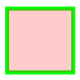

In [10]:
importlib.reload(vector_layer)
symbol = [
            [
               ["PolygonSymbolizer", "fill", '#ff0000'],
               ["PolygonSymbolizer", "fill-opacity", 0.2],
               ["LineSymbolizer", "stroke", "#00ff00"],
               ["LineSymbolizer", "stroke-width", 4.0]
            ]
]
vector_layer.symbol2Image(symbol, feature='Polygon', size=2, showborder=False)

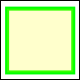

In [11]:
from IPython.display import display
importlib.reload(vector_layer)

symbol = [
            [
               ["PolygonSymbolizer", "fill", 'yellow'],
               ["PolygonSymbolizer", "fill-opacity", 0.2],
               ["LineSymbolizer", "stroke", "#00ff00"],
               ["LineSymbolizer", "stroke-width", 4.0]
            ]
]

# Create the image
img = vector_layer.symbol2Image(symbol, feature='Polygon', size=2, showborder=True)

# Display the image
display(img)

### POSTGIS query

In [ ]:
#%run ../../development/load_local_vois.py -w
from vois.geo import Map
from vectorlayer import vectorlayer

vlayer = vectorlayer.postgis(
            host="db-001.cidsn.jrc.it",
            port=54333,
            dbname="sais_db",
            user="XXXXXX",
            password="YYYYYY",
            query="SELECT geom FROM sais_dev.dk_sq_extent",
            epsg=3035,
            geomtype="Polygon",
            extents="4200207.5 3496795.9,4649995.8 3848272.9"
)

symbol = [
            [
               ["PolygonSymbolizer", "fill", '#ff0000'],
               ["PolygonSymbolizer", "fill-opacity", 0.3],
               ["LineSymbolizer", "stroke", "#000000"],
               ["LineSymbolizer", "stroke-width", 1.0]
            ]
]

vlayer.symbologyClear()
vlayer.symbologyAdd(symbol=symbol)
#vlayer.print()


m = Map.Map(center=[56, 12], zoom=6)
m.addLayer(vlayer)
m.onclick = vlayer.onclick
vlayer.identify_fields = ['FID', 'GEOMETRY']
m